In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [23]:
df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [24]:
df.drop(columns=['PassengerId'], inplace=True)
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 76.7+ KB


In [26]:
df.isna().sum().sort_values(ascending=False)

Cabin       687
Age         177
Embarked      2
Name          0
Pclass        0
Survived      0
Sex           0
Parch         0
SibSp         0
Fare          0
Ticket        0
dtype: int64

In [27]:
df.groupby('Pclass')['Cabin'].apply(lambda x: x.isna().sum())

Pclass
1     40
2    168
3    479
Name: Cabin, dtype: int64

In [28]:
df['Has_Cabin'] = df['Cabin'].notna().astype(int)
df = df.drop('Cabin', axis=1)

In [29]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


In [30]:
df.groupby('Sex')['Age'].apply(lambda x: x.isna().sum())

Sex
female     53
male      124
Name: Age, dtype: int64

In [32]:
df['Age'] = df['Age'].fillna(df.groupby('Sex')['Age'].transform('mean'))
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


In [33]:
df.isna().sum().sort_values(ascending=False)

Embarked     2
Pclass       0
Survived     0
Name         0
Sex          0
SibSp        0
Age          0
Parch        0
Ticket       0
Fare         0
Has_Cabin    0
dtype: int64

In [34]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [36]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [37]:
df.isna().sum().sort_values(ascending=False)

Survived     0
Pclass       0
Name         0
Sex          0
Age          0
SibSp        0
Parch        0
Ticket       0
Fare         0
Embarked     0
Has_Cabin    0
dtype: int64

In [38]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,891.0,29.736034,13.014897,0.42,22.0000,30.0000,35.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292
Has_Cabin,891.0,0.228956,0.420397,0.00,0.0000,0.0000,0.0,1.0000


In [39]:
df.shape

(891, 11)

In [42]:
df['Survived'].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [43]:
df.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Embarked', 'Has_Cabin'],
      dtype='object')

In [44]:
df = df.drop(columns=['Name', 'Ticket'])
df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Has_Cabin
0,0,3,male,22.0,1,0,7.2500,S,0
1,1,1,female,38.0,1,0,71.2833,C,1
2,1,3,female,26.0,0,0,7.9250,S,0
3,1,1,female,35.0,1,0,53.1000,S,1
4,0,3,male,35.0,0,0,8.0500,S,0


One-Hot Encode(Categorical Columns): Sex, Embarked
Keep As-is (already numeric, meaningful): Age, SibSp, Parch, Fare,Pclass

In [45]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
encoder.set_output(transform='pandas')

encoded_df = encoder.fit_transform(df[['Sex', 'Embarked']])

print(encoded_df)

     Sex_male  Embarked_Q  Embarked_S
0         1.0         0.0         1.0
1         0.0         0.0         0.0
2         0.0         0.0         1.0
3         0.0         0.0         1.0
4         1.0         0.0         1.0
..        ...         ...         ...
886       1.0         0.0         1.0
887       0.0         0.0         1.0
888       0.0         0.0         1.0
889       1.0         0.0         0.0
890       1.0         1.0         0.0

[891 rows x 3 columns]


In [46]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Has_Cabin
0,0,3,male,22.0,1,0,7.2500,S,0
1,1,1,female,38.0,1,0,71.2833,C,1
2,1,3,female,26.0,0,0,7.9250,S,0
3,1,1,female,35.0,1,0,53.1000,S,1
4,0,3,male,35.0,0,0,8.0500,S,0


In [47]:
df = df.drop(columns = ['Sex', 'Embarked'])
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Has_Cabin
0,0,3,22.0,1,0,7.2500,0
1,1,1,38.0,1,0,71.2833,1
2,1,3,26.0,0,0,7.9250,0
3,1,1,35.0,1,0,53.1000,1
4,0,3,35.0,0,0,8.0500,0


In [48]:
final_df = pd.concat([df, encoded_df], axis=1)

final_df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Has_Cabin,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,0,1.0,0.0,1.0
1,1,1,38.0,1,0,71.2833,1,0.0,0.0,0.0
2,1,3,26.0,0,0,7.9250,0,0.0,0.0,1.0
3,1,1,35.0,1,0,53.1000,1,0.0,0.0,1.0
4,0,3,35.0,0,0,8.0500,0,1.0,0.0,1.0


In [49]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Age         891 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-null    float64
 6   Has_Cabin   891 non-null    int64  
 7   Sex_male    891 non-null    float64
 8   Embarked_Q  891 non-null    float64
 9   Embarked_S  891 non-null    float64
dtypes: float64(5), int64(5)
memory usage: 69.7 KB


In [50]:
final_df.dtypes

Survived        int64
Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Has_Cabin       int64
Sex_male      float64
Embarked_Q    float64
Embarked_S    float64
dtype: object

In [51]:
X = final_df.drop(columns=['Survived'])
y = final_df['Survived']

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y
)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (712, 9)
Testing features shape: (179, 9)


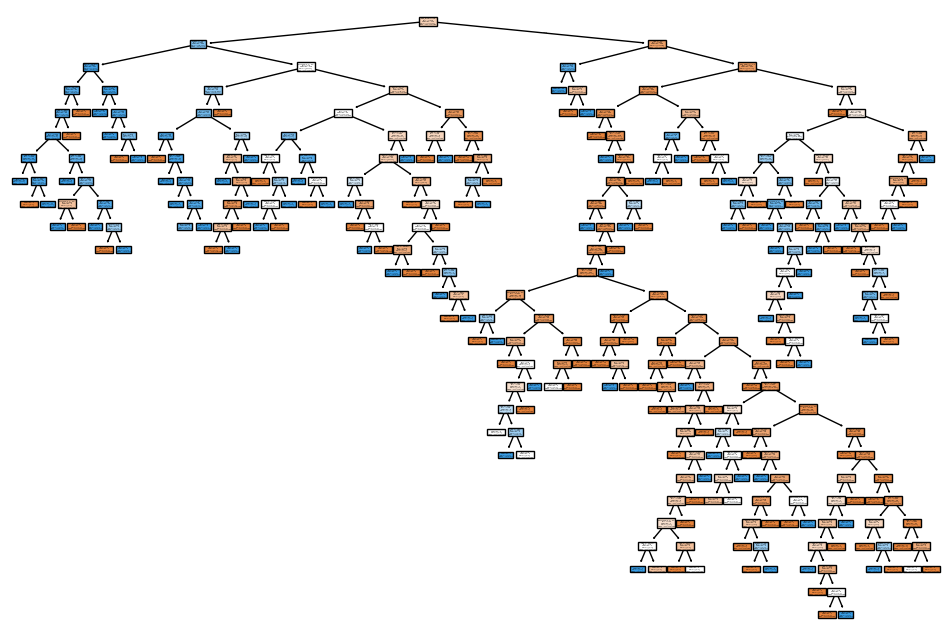

In [68]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
dt = DecisionTreeClassifier(max_depth=None, random_state=42)

dt.fit(X_train, y_train)

predictions = dt.predict(X_test)

plt.figure(figsize=(12, 8))
plot_tree(dt, filled=True, feature_names=X.columns, class_names=['Not Survived', 'Survived'])
plt.show()

In [69]:

train_acc = dt.score(X_train, y_train)

test_acc = dt.score(X_test, y_test)

In [70]:
train_acc

0.9859550561797753

In [71]:
test_acc

0.7932960893854749

In [72]:
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")

Train Accuracy: 0.9860
Test Accuracy:  0.7933


In [75]:
from sklearn.model_selection import cross_val_score

dt_cv = DecisionTreeClassifier(max_depth=None, random_state=42)
cv_scores = cross_val_score(dt_cv, X, y, cv=5, scoring='accuracy')

print("=== 5-FOLD CROSS-VALIDATION ===")
print(f"Fold-wise scores: {np.round(cv_scores, 4)}")
print(f"CV Mean Accuracy: {cv_scores.mean():.4f}")
print(f"CV Std Deviation: {cv_scores.std():.4f}")

=== 5-FOLD CROSS-VALIDATION ===
Fold-wise scores: [0.743  0.7753 0.8202 0.7472 0.8371]
CV Mean Accuracy: 0.7846
CV Std Deviation: 0.0380


In [76]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
rf.fit(X_train, y_train)

# Check karo:
print("RF Train Accuracy:", rf.score(X_train, y_train))
print("RF Test Accuracy:", rf.score(X_test, y_test))

RF Train Accuracy: 0.9859550561797753
RF Test Accuracy: 0.770949720670391


In [77]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)

rf_cv_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')

print('RF CV Scores:', rf_cv_scores)
print('RF CV Mean:', rf_cv_scores.mean())
print('RF CV Std:', rf_cv_scores.std())

RF CV Scores: [0.81005587 0.78089888 0.84831461 0.78651685 0.85393258]
RF CV Mean: 0.8159437574540205
RF CV Std: 0.030396632878517963


In [78]:
rf_oob = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
rf_oob.fit(X_train, y_train)
print("OOB Score:", rf_oob.oob_score_)

OOB Score: 0.8132022471910112


In [79]:
grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)     # sirf TRAIN data — test abhi bhi sealed hai

print("Best params:", grid_search.best_params_)

# Ab best params se final model banao aur fair comparison karo
best_gb = grid_search.best_estimator_   # yeh already X_train pe fitted hai

train_acc = best_gb.score(X_train, y_train)
test_acc = best_gb.score(X_test, y_test)   # ab yeh genuinely "unseen" hai

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")

Best params: {'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 100}
Train Accuracy: 0.8947
Test Accuracy:  0.7877


In [80]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

gb_cv = GradientBoostingClassifier(
    learning_rate=0.2, max_depth=2, n_estimators=100, random_state=42
)
gb_cv_scores = cross_val_score(gb_cv, X, y, cv=5, scoring='accuracy')

print("GB CV Scores:", np.round(gb_cv_scores, 4))
print("GB CV Mean:", gb_cv_scores.mean())
print("GB CV Std:", gb_cv_scores.std())

GB CV Scores: [0.8156 0.8202 0.8427 0.7978 0.8539]
GB CV Mean: 0.8260498399347185
GB CV Std: 0.019987649259799182
